# Machine Learning terms and metrics

Module 1, Lab 2

In this lab, we will show a part of the ML pipeline by using the California Housing dataset. There are 20640 samples, each with 8 attributes like income of the block, age of the houses per district etc. The task is to predict the cost of the houses per district. We will use the scikit-learn library to load the data and perform some basic data preprocessing and model training. We will also show how to evaluate the model using some common metrics, split the data into training and testing sets, and use cross-validation to get a better estimate of the model's performance.

## Common Machine Learning Evaluation Metrics

### Classification Metrics

**1. Accuracy**
$$\text{Accuracy} = \frac{\text{Correct Predictions}}{\text{Total Predictions}} = \frac{TP + TN}{TP + TN + FP + FN}$$

**2. Precision** (How many predicted positives are actually positive?)
$$\text{Precision} = \frac{TP}{TP + FP}$$

**3. Recall/Sensitivity** (How many actual positives did we find?)
$$\text{Recall} = \frac{TP}{TP + FN}$$

**4. F1-Score** (Harmonic mean of Precision and Recall)
$$\text{F1} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

Where: **TP** = True Positives, **TN** = True Negatives, **FP** = False Positives, **FN** = False Negatives

### Regression Metrics

**1. Mean Absolute Error (MAE)**
$$\text{MAE} = \frac{1}{n}\sum_{i=1}^{n}|y_i - \hat{y}_i|$$

**2. Mean Squared Error (MSE)**
$$\text{MSE} = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2$$

**3. Root Mean Squared Error (RMSE)**
$$\text{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}$$

---

In [1]:
import numpy as np
from sklearn import datasets
import matplotlib.pyplot as plt

rng = np.random.default_rng(seed=42)

In [2]:
dataset = datasets.fetch_california_housing()
# Dataset description
print(dataset.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

Given below are the list of target values. These correspond to the house value derived considering all the 8 input features and are continuous values. We should use regression models to predict these values but we will start with a simple classification model for the sake of simplicity. We need to just round off the values to the nearest integer and use a classification model to predict the house value.

In [3]:
print("Orignal target values:", dataset.target)

dataset.target = dataset.target.astype(int)

print("Target values after conversion:", dataset.target)
print("Input variables shape:", dataset.data.shape)
print("Output variables shape:", dataset.target.shape)

Orignal target values: [4.526 3.585 3.521 ... 0.923 0.847 0.894]
Target values after conversion: [4 3 3 ... 0 0 0]
Input variables shape: (20640, 8)
Output variables shape: (20640,)


The simplest model to use for classification is the K-Nearest Neighbors model. We will use this model to predict the house value with a K value of 1. We will also use the accuracy metric to evaluate the model.

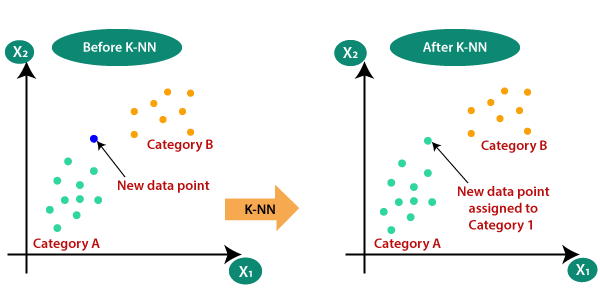

In [4]:
def NN1(traindata, trainlabel, query):
    """
    This function takes in the training data, training labels and a query point
    and returns the predicted label for the query point using the nearest neighbour algorithm

    traindata: numpy array of shape (n,d) where n is the number of samples and d is the number of features
    trainlabel: numpy array of shape (n,) where n is the number of samples
    query: numpy array of shape (d,) where d is the number of features

    returns: the predicted label for the query point which is the label of the training data which is closest to the query point
    """
    diff = (
        traindata - query
    )  # find the difference between features. Numpy automatically takes care of the size here
    sq = diff * diff  # square the differences
    dist = sq.sum(1)  # add up the squares
    label = trainlabel[np.argmin(dist)]
    return label


def NN(traindata, trainlabel, testdata):
    """
    This function takes in the training data, training labels and test data
    and returns the predicted labels for the test data using the nearest neighbour algorithm

    traindata: numpy array of shape (n,d) where n is the number of samples and d is the number of features
    trainlabel: numpy array of shape (n,) where n is the number of samples
    testdata: numpy array of shape (m,d) where m is the number of test samples and d is the number of features

    returns: the predicted labels for the test data which is the label of the training data which is closest to each test point
    """
    predlabel = np.array([NN1(traindata, trainlabel, i) for i in testdata])
    return predlabel

We will also define a 'random classifier', which randomly allots labels to each sample

In [5]:
def RandomClassifier(traindata, trainlabel, testdata):
    """
    This function takes in the training data, training labels and test data
    and returns the predicted labels for the test data using the random classifier algorithm

    In reality, we don't need these arguments but we are passing them to keep the function signature consistent with other classifiers

    traindata: numpy array of shape (n,d) where n is the number of samples and d is the number of features
    trainlabel: numpy array of shape (n,) where n is the number of samples
    testdata: numpy array of shape (m,d) where m is the number of test samples and d is the number of features

    returns: the predicted labels for the test data which is a random label from the training data
    """

    classes = np.unique(trainlabel)
    rints = rng.integers(low=0, high=len(classes), size=len(testdata))
    predlabel = classes[rints]
    return predlabel

We need a metric to evaluate the performance of the model. Let us define a metric 'Accuracy' to see how good our learning algorithm is. Accuracy is the ratio of the number of correctly classified samples to the total number of samples. The higher the accuracy, the better the algorithm. We will use the accuracy metric to evaluate and compate the performance of the K-Nearest Neighbors model and the random classifier.

In [6]:
def Accuracy(gtlabel, predlabel):
    """
    This function takes in the ground-truth labels and predicted labels
    and returns the accuracy of the classifier

    gtlabel: numpy array of shape (n,) where n is the number of samples
    predlabel: numpy array of shape (n,) where n is the number of samples

    returns: the accuracy of the classifier which is the number of correct predictions divided by the total number of predictions
    """
    assert len(gtlabel) == len(
        predlabel
    ), "Length of the ground-truth labels and predicted labels should be the same"
    correct = (
        gtlabel == predlabel
    ).sum()  # count the number of times the groundtruth label is equal to the predicted label.
    return correct / len(gtlabel)

Let us make a function to split the dataset with the desired probability. We will use this function to split the dataset into training and testing sets. We will use the training set to train the model and the testing set to evaluate the model.

In [7]:
def split(data, label, percent):
    # generate a random number for each sample
    rnd = rng.random(len(label))
    split1 = rnd < percent
    split2 = rnd >= percent

    split1data = data[split1, :]
    split1label = label[split1]
    split2data = data[split2, :]
    split2label = label[split2]
    return split1data, split1label, split2data, split2label

We will reserve 20% of our dataset as the test set. We will not change this portion throughout our experiments

In [8]:
testdata, testlabel, alltraindata, alltrainlabel = split(
    dataset.data, dataset.target, 20 / 100
)
print("Number of test samples:", len(testlabel))
print("Number of train samples:", len(alltrainlabel))
print("Percent of test data:", len(testlabel) * 100 / len(dataset.target), "%")

Number of test samples: 4144
Number of train samples: 16496
Percent of test data: 20.07751937984496 %


## Experiments with splits

Let us reserve some of our train data as a validation set

In [9]:
traindata, trainlabel, valdata, vallabel = split(
    alltraindata, alltrainlabel, 75 / 100)

In [10]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def print_classification_metrics(true_labels, pred_labels):
    """
    Calculate and print classification metrics
    """
    # For multi-class, we'll use macro averaging
    precision = precision_score(true_labels, pred_labels, average='macro', zero_division=0)
    recall = recall_score(true_labels, pred_labels, average='macro', zero_division=0)
    f1 = f1_score(true_labels, pred_labels, average='macro', zero_division=0)
    accuracy = np.mean(true_labels == pred_labels)

    print(f"Accuracy:  {accuracy*100:.2f}%")
    print(f"Precision: {precision*100:.2f}%")
    print(f"Recall:    {recall*100:.2f}%")
    print(f"F1-Score:  {f1*100:.2f}%")

    return accuracy, precision, recall, f1

def print_regression_metrics(true_values, pred_values):
    """
    Calculate and print regression metrics
    """
    mae = mean_absolute_error(true_values, pred_values)
    mse = mean_squared_error(true_values, pred_values)
    rmse = np.sqrt(mse)

    print(f"MAE:  {mae:.4f}")
    print(f"MSE:  {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")

    return mae, mse, rmse

# Example: Evaluate validation set with multiple metrics
print("=== Validation Set Classification Metrics ===")
valpred = NN(traindata, trainlabel, valdata)
print_classification_metrics(vallabel, valpred)

=== Validation Set Classification Metrics ===
Accuracy:  34.11%
Precision: 26.19%
Recall:    24.41%
F1-Score:  25.01%


(np.float64(0.34108527131782945),
 0.2618519014073886,
 0.2440802242008584,
 0.2501492638552703)

=== Confusion Matrix for Validation Set ===


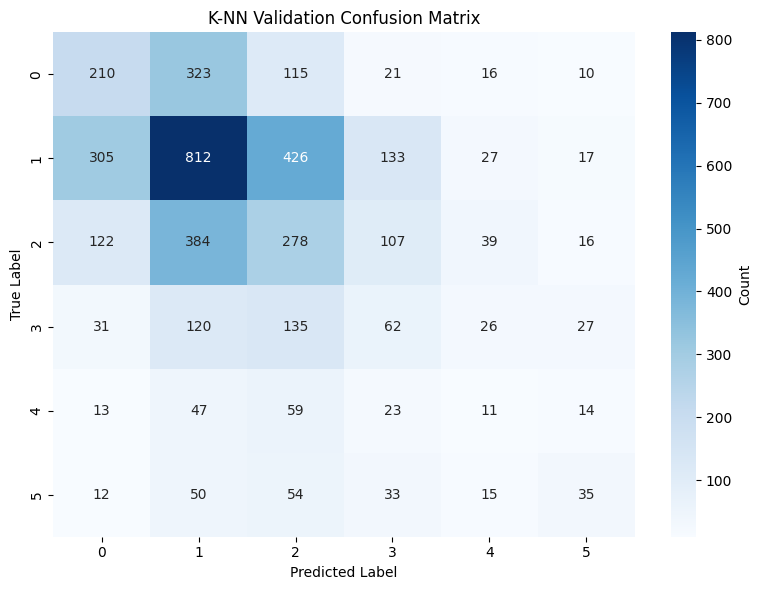

Confusion Matrix Shape: (6, 6)
Total Predictions: 4128


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_confusion_matrix(true_labels, pred_labels, title="Confusion Matrix"):
    """
    Plot confusion matrix heatmap
    """
    cm = confusion_matrix(true_labels, pred_labels)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                cbar_kws={'label': 'Count'})
    plt.title(title)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

    print(f"Confusion Matrix Shape: {cm.shape}")
    print(f"Total Predictions: {cm.sum()}")

# Visualize confusion matrix for validation predictions
print("=== Confusion Matrix for Validation Set ===")
valpred = NN(traindata, trainlabel, valdata)
plot_confusion_matrix(vallabel, valpred,
                     title="K-NN Validation Confusion Matrix")

What is the accuracy of our classifiers on the train dataset?

In [12]:
trainpred = NN(traindata, trainlabel, traindata)
trainAccuracy = Accuracy(trainlabel, trainpred)
print("Training accuracy using nearest neighbour algorithm:", trainAccuracy*100, "%")

trainpred = RandomClassifier(traindata, trainlabel, traindata)
trainAccuracy = Accuracy(trainlabel, trainpred)
print("Training accuracy using random classifier: ", trainAccuracy*100, "%")

Training accuracy using nearest neighbour algorithm: 100.0 %
Training accuracy using random classifier:  16.4375808538163 %


For nearest neighbour, the train accuracy is always 1. The accuracy of the random classifier is close to 1/(number of classes) which is 0.1666 in our case. This is because the random classifier randomly assigns a label to each sample and the probability of assigning the correct label is 1/(number of classes). Let us predict the labels for our validation set and get the accuracy. This accuracy is a good estimate of the accuracy of our model on unseen data.

In [13]:
valpred = NN(traindata, trainlabel, valdata)
valAccuracy = Accuracy(vallabel, valpred)
print("Validation accuracy using nearest neighbour algorithm:", valAccuracy*100, "%")


valpred = RandomClassifier(traindata, trainlabel, valdata)
valAccuracy = Accuracy(vallabel, valpred)
print("Validation accuracy using random classifier:", valAccuracy*100, "%")

Validation accuracy using nearest neighbour algorithm: 34.10852713178294 %
Validation accuracy using random classifier: 16.884689922480618 %


Validation accuracy of nearest neighbour is considerably less than its train accuracy while the validation accuracy of random classifier is the same. However, the validation accuracy of nearest neighbour is twice that of the random classifier. Now let us try another random split and check the validation accuracy. We will see that the validation accuracy changes with the split. This is because the validation set is small and the accuracy is highly dependent on the samples in the validation set. We can get a better estimate of the accuracy by using cross-validation.

In [14]:
traindata, trainlabel, valdata, vallabel = split(
    alltraindata, alltrainlabel, 75 / 100)
valpred = NN(traindata, trainlabel, valdata)
valAccuracy = Accuracy(vallabel, valpred)
print("Validation accuracy using nearest neighbour algorithm:", valAccuracy*100, "%")

Validation accuracy using nearest neighbour algorithm: 34.048257372654156 %


You can run the above cell multiple times to try with different random splits.
We notice that the accuracy is different for each run, but close together.

Now let us compare it with the accuracy we get on the test dataset.

In [15]:
testpred = NN(alltraindata, alltrainlabel, testdata)
testAccuracy = Accuracy(testlabel, testpred)

print("Test accuracy:", testAccuracy*100, "%")

Test accuracy: 34.91795366795367 %


### Try it out for yourself and answer:
1. How is the accuracy of the validation set affected if we increase the percentage of validation set? What happens when we reduce it?
2. How does the size of the train and validation set affect how well we can predict the accuracy on the test set using the validation set?
3. What do you think is a good percentage to reserve for the validation set so that thest two factors are balanced?

Answer for both nearest neighbour and random classifier. You can note down the values for your experiments and plot a graph using  <a href=https://matplotlib.org/stable/gallery/lines_bars_and_markers/step_demo.html#sphx-glr-gallery-lines-bars-and-markers-step-demo-py>plt.plot<href>. Check also for extreme values for splits, like 99.9% or 0.1%

## Answers — Try it out for yourself

### 1. What happens when we increase or reduce the validation-set percentage?

**Nearest Neighbour (1-NN):**  
- If the validation set becomes larger, there are more samples on which accuracy is measured, so the estimate usually becomes less dependent on any one sample.  
- However, making validation larger leaves fewer samples for training, which can reduce the model's ability to learn from the data.
- If the validation set becomes very small, the measured accuracy can change a lot from one random split to another because only a few validation samples are being tested.

**Random Classifier:**  
- Its accuracy is expected to stay around the probability of randomly selecting the correct class (roughly `1 / number_of_classes`), so changing the split size should not systematically improve the classifier.
- Because it is random, individual runs can still fluctuate.

### 2. How does train/validation size affect estimating test accuracy?

There is a trade-off:
- **More training data:** the learned 1-NN model has more examples to compare against, but fewer validation examples are available to estimate performance.
- **More validation data:** the validation accuracy is based on more examples and is usually more stable, but the model is trained on fewer examples.
- Therefore, an extremely small validation set gives a noisy estimate, while an extremely small training set can make the validation estimate less representative of the model trained with all available training data.

### 3. What is a good validation percentage?

There is no single universal percentage. For this lab, **around 20–30% of the training portion** is a reasonable practical starting point because it leaves most of the data for training while keeping a useful number of validation examples.

The code below tests several split sizes for **both 1-NN and the random classifier**. The exact numbers will vary because the notebook intentionally uses random splits.

> **Important:** the original notebook fixes 20% of the full dataset as the test set. The experiments below change only the train/validation split inside the remaining 80%, so the test set remains untouched.


Validation percentages: [0.1, 0.2, 0.3, 0.4, 0.5, 0.7, 0.9, 0.999]
1-NN accuracies: [np.float64(0.3504424778761062), np.float64(0.34915254237288135), np.float64(0.3373253493013972), np.float64(0.33266993263931416), np.float64(0.3308527510064658), np.float64(0.31438243208054856), np.float64(0.3005920344456405), np.float64(0.17683814608104828)]
Random-classifier accuracies: [np.float64(0.16283185840707964), np.float64(0.16887519260400616), np.float64(0.16686626746506986), np.float64(0.16625842008573177), np.float64(0.16445040868610467), np.float64(0.16856175679194516), np.float64(0.1652314316469322), np.float64(0.1954622664401844)]


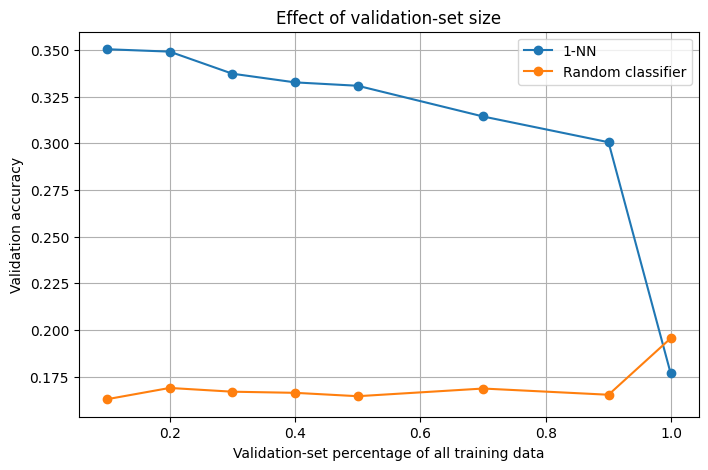

In [16]:
# Explore different validation percentages.
# Run this cell in the notebook after the existing split/function cells.

validation_percentages = [0.1, 0.2, 0.3, 0.4, 0.5, 0.7, 0.9, 0.999]

nn_results = []
random_results = []

for val_percent in validation_percentages:
    # val_percent is the fraction reserved for validation.
    # The training fraction is therefore 1 - val_percent.
    traindata, trainlabel, valdata, vallabel = split(
        alltraindata, alltrainlabel, 1 - val_percent
    )

    nn_pred = NN(traindata, trainlabel, valdata)
    random_pred = RandomClassifier(traindata, trainlabel, valdata)

    nn_results.append(Accuracy(vallabel, nn_pred))
    random_results.append(Accuracy(vallabel, random_pred))

print("Validation percentages:", validation_percentages)
print("1-NN accuracies:", nn_results)
print("Random-classifier accuracies:", random_results)

plt.figure(figsize=(8, 5))
plt.plot(validation_percentages, nn_results, marker="o", label="1-NN")
plt.plot(validation_percentages, random_results, marker="o", label="Random classifier")
plt.xlabel("Validation-set percentage of all training data")
plt.ylabel("Validation accuracy")
plt.title("Effect of validation-set size")
plt.legend()
plt.grid(True)
plt.show()


> Exercise: Try to implement a 3 nearest neighbour classifier and compare the accuracy of the 1 nearest neighbour classifier and the 3 nearest neighbour classifier on the test dataset. You can use the KNeighborsClassifier class from the scikit-learn library to implement the K-Nearest Neighbors model. You can set the number of neighbors using the n_neighbors parameter. You can also use the accuracy_score function from the scikit-learn library to calculate the accuracy of the model.

## Exercise Solution — 3-Nearest Neighbour

A 3-nearest-neighbour classifier predicts the class by looking at the **three closest training samples** and taking the majority class among those three neighbours.

We compare it with the original 1-NN classifier on the **same untouched test set**.


In [17]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# 1-NN
knn1 = KNeighborsClassifier(n_neighbors=1)
knn1.fit(alltraindata, alltrainlabel)
pred1 = knn1.predict(testdata)
acc1 = accuracy_score(testlabel, pred1)

# 3-NN
knn3 = KNeighborsClassifier(n_neighbors=3)
knn3.fit(alltraindata, alltrainlabel)
pred3 = knn3.predict(testdata)
acc3 = accuracy_score(testlabel, pred3)

print(f"1-NN test accuracy: {acc1 * 100:.2f}%")
print(f"3-NN test accuracy: {acc3 * 100:.2f}%")
print("1-NN and 3-NN use the same training and test sets.")


1-NN test accuracy: 34.92%
3-NN test accuracy: 36.05%
1-NN and 3-NN use the same training and test sets.


## Multiple Splits

One way to get more accurate estimates for the test accuracy is by using <b>cross-validation</b>. Here, we will try a simple version, where we do multiple train/val splits and take the average of validation accuracies as the test accuracy estimation. Here is a function for doing this. Note that this function will take a long time to execute. You can reduce the number of splits to make it faster.

In [18]:
def AverageAccuracy(alldata, alllabel, splitpercent, iterations, classifier=NN):
    """
    This function takes in the data, labels, split percentage, number of iterations and classifier function
    and returns the average accuracy of the classifier

    alldata: numpy array of shape (n,d) where n is the number of samples and d is the number of features
    alllabel: numpy array of shape (n,) where n is the number of samples
    splitpercent: float which is the percentage of data to be used for training
    iterations: int which is the number of iterations to run the classifier
    classifier: function which is the classifier function to be used

    returns: the average accuracy of the classifier
    """
    accuracy = 0
    for ii in range(iterations):
        traindata, trainlabel, valdata, vallabel = split(
            alldata, alllabel, splitpercent
        )
        valpred = classifier(traindata, trainlabel, valdata)
        accuracy += Accuracy(vallabel, valpred)
    return accuracy / iterations  # average of all accuracies

In [19]:
avg_acc = AverageAccuracy(alltraindata, alltrainlabel, 75 / 100, 10, classifier=NN)
print("Average validation accuracy:", avg_acc*100, "%")
testpred = NN(alltraindata, alltrainlabel, testdata)

print("Test accuracy:", Accuracy(testlabel, testpred)*100, "%")

Average validation accuracy: 34.12135614741179 %
Test accuracy: 34.91795366795367 %


This is a very simple way of doing cross-validation. There are many well-known algorithms for cross-validation, like k-fold cross-validation, leave-one-out etc. This will be covered in detail in a later module. For more information about cross-validation, check <a href=https://en.wikipedia.org/wiki/Cross-validation_(statistics)>Cross-validatioin (Wikipedia)</a>

### Questions
1. Does averaging the validation accuracy across multiple splits give more consistent results?
2. Does it give more accurate estimate of test accuracy?
3. What is the effect of the number of iterations on the estimate? Do we get a better estimate with higher iterations?
4. Consider the results you got for the previous questions. Can we deal with a very small train dataset or validation dataset by increasing the iterations?


## Answers — Multiple Splits / Cross-validation

### 1. Does averaging validation accuracy across multiple splits give more consistent results?

**Yes, generally.** A single random train/validation split can give a high or low accuracy simply because of which samples happened to enter the validation set. Averaging over many random splits reduces the influence of any one split.

### 2. Does it give a more accurate estimate of test accuracy?

**Usually it gives a more stable estimate of expected validation performance**, and it can be a better estimate than relying on one small validation set. It is still an estimate, not a guarantee that it will exactly equal the final test accuracy.

### 3. What is the effect of the number of iterations?

As the number of random splits increases, the average generally becomes more stable. With only a few iterations, the average can change noticeably from run to run. With more iterations, the average tends to settle toward a more stable value.

### 4. Can we solve a very small train or validation dataset just by increasing iterations?

**No.** Increasing iterations gives more repeated measurements, but it does not create new information inside a single train/validation split. If the training set is too small, the model still has too little data to learn from. If the validation set is too small, each individual validation accuracy is still noisy.

More iterations can reduce randomness in the **average**, but they cannot replace having a sufficiently representative training and validation set.


 1 iterations -> average validation accuracy: 34.30%
 5 iterations -> average validation accuracy: 34.05%
10 iterations -> average validation accuracy: 34.04%
25 iterations -> average validation accuracy: 34.02%
50 iterations -> average validation accuracy: 34.01%


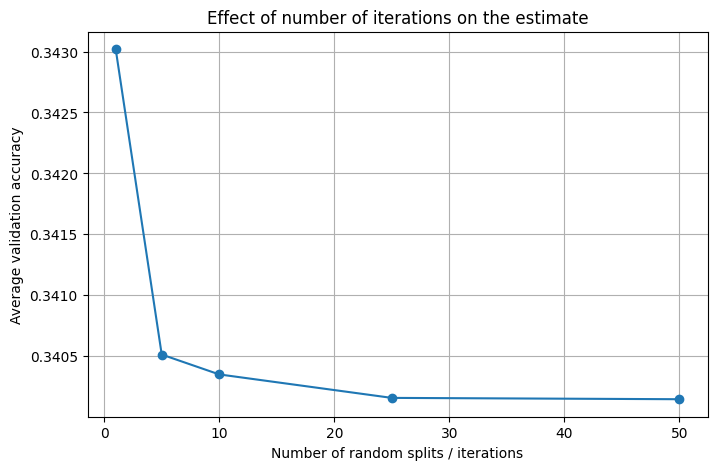

In [20]:
# Demonstrate how the estimated accuracy changes as the number of iterations increases.

iteration_values = [1, 5, 10, 25, 50]
iteration_estimates = []

for n_iter in iteration_values:
    estimate = AverageAccuracy(
        alltraindata,
        alltrainlabel,
        75 / 100,
        n_iter,
        classifier=NN
    )
    iteration_estimates.append(estimate)

for n_iter, estimate in zip(iteration_values, iteration_estimates):
    print(f"{n_iter:>2} iterations -> average validation accuracy: {estimate * 100:.2f}%")

plt.figure(figsize=(8, 5))
plt.plot(iteration_values, iteration_estimates, marker="o")
plt.xlabel("Number of random splits / iterations")
plt.ylabel("Average validation accuracy")
plt.title("Effect of number of iterations on the estimate")
plt.grid(True)
plt.show()


> Exercise: How does the accuracy of the 3 nearest neighbour classifier change with the number of splits? How is it affected by the split size? Compare the results with the 1 nearest neighbour classifier.

## Exercise Solution — 3-NN with Different Numbers of Splits and Split Sizes

For this exercise, we compare **3-NN** with **1-NN** while changing:

1. the number of random train/validation splits used for the average, and
2. the train/validation split size.

The held-out test set remains unchanged.


Number of splits: [1, 5, 10, 25, 50]
1-NN: [33.96, 33.87, 33.71, 34.11, 34.04]
3-NN: [33.97, 34.71, 34.23, 34.63, 34.58]


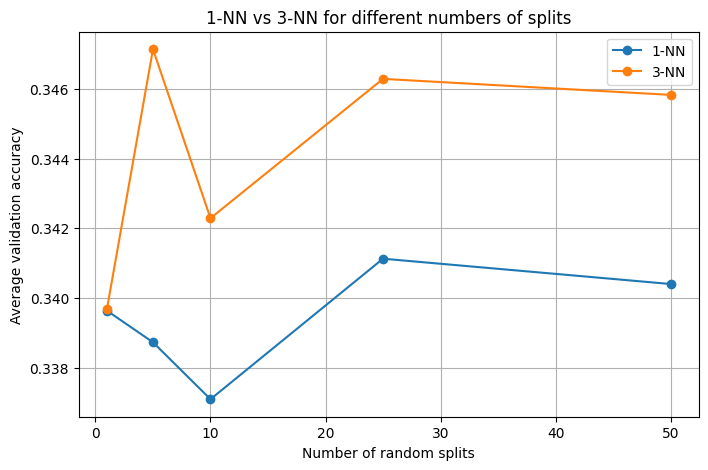

In [21]:
# Compare 1-NN and 3-NN for different numbers of random splits.

def sklearn_knn_classifier(traindata, trainlabel, testdata, k):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(traindata, trainlabel)
    return model.predict(testdata)

def average_accuracy_sklearn_knn(alldata, alllabel, train_fraction, iterations, k):
    total = 0.0

    for _ in range(iterations):
        traindata, trainlabel, valdata, vallabel = split(
            alldata, alllabel, train_fraction
        )
        pred = sklearn_knn_classifier(traindata, trainlabel, valdata, k)
        total += accuracy_score(vallabel, pred)

    return total / iterations

split_iterations = [1, 5, 10, 25, 50]
nn1_by_iterations = []
nn3_by_iterations = []

for n_iter in split_iterations:
    nn1_by_iterations.append(
        average_accuracy_sklearn_knn(
            alltraindata, alltrainlabel, 0.75, n_iter, 1
        )
    )
    nn3_by_iterations.append(
        average_accuracy_sklearn_knn(
            alltraindata, alltrainlabel, 0.75, n_iter, 3
        )
    )

print("Number of splits:", split_iterations)
print("1-NN:", [round(x * 100, 2) for x in nn1_by_iterations])
print("3-NN:", [round(x * 100, 2) for x in nn3_by_iterations])

plt.figure(figsize=(8, 5))
plt.plot(split_iterations, nn1_by_iterations, marker="o", label="1-NN")
plt.plot(split_iterations, nn3_by_iterations, marker="o", label="3-NN")
plt.xlabel("Number of random splits")
plt.ylabel("Average validation accuracy")
plt.title("1-NN vs 3-NN for different numbers of splits")
plt.legend()
plt.grid(True)
plt.show()


Training fractions: [0.1, 0.25, 0.5, 0.75, 0.9, 0.99]
1-NN: [29.36, 31.36, 33.03, 33.96, 34.65, 37.09]
3-NN: [30.66, 32.1, 33.43, 34.62, 35.1, 34.78]


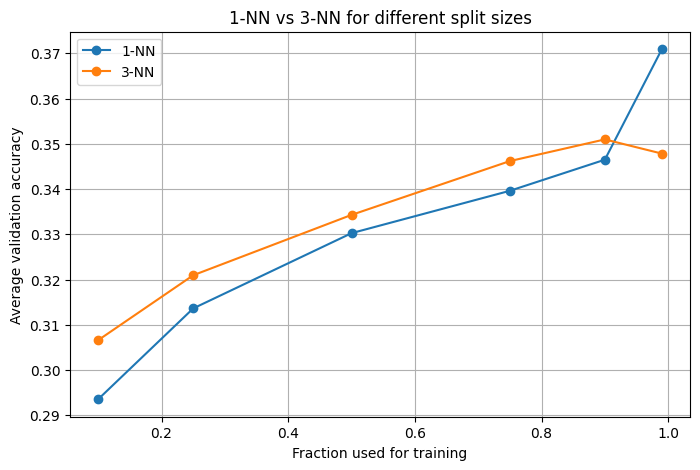

In [22]:
# Compare 1-NN and 3-NN for different train/validation split sizes.

train_fractions = [0.1, 0.25, 0.5, 0.75, 0.9, 0.99]
nn1_by_split = []
nn3_by_split = []

for train_fraction in train_fractions:
    nn1_by_split.append(
        average_accuracy_sklearn_knn(
            alltraindata, alltrainlabel, train_fraction, 10, 1
        )
    )
    nn3_by_split.append(
        average_accuracy_sklearn_knn(
            alltraindata, alltrainlabel, train_fraction, 10, 3
        )
    )

print("Training fractions:", train_fractions)
print("1-NN:", [round(x * 100, 2) for x in nn1_by_split])
print("3-NN:", [round(x * 100, 2) for x in nn3_by_split])

plt.figure(figsize=(8, 5))
plt.plot(train_fractions, nn1_by_split, marker="o", label="1-NN")
plt.plot(train_fractions, nn3_by_split, marker="o", label="3-NN")
plt.xlabel("Fraction used for training")
plt.ylabel("Average validation accuracy")
plt.title("1-NN vs 3-NN for different split sizes")
plt.legend()
plt.grid(True)
plt.show()
